Target Missed (sim ended at Tmax)
Miss Distance = 343607.5657090335


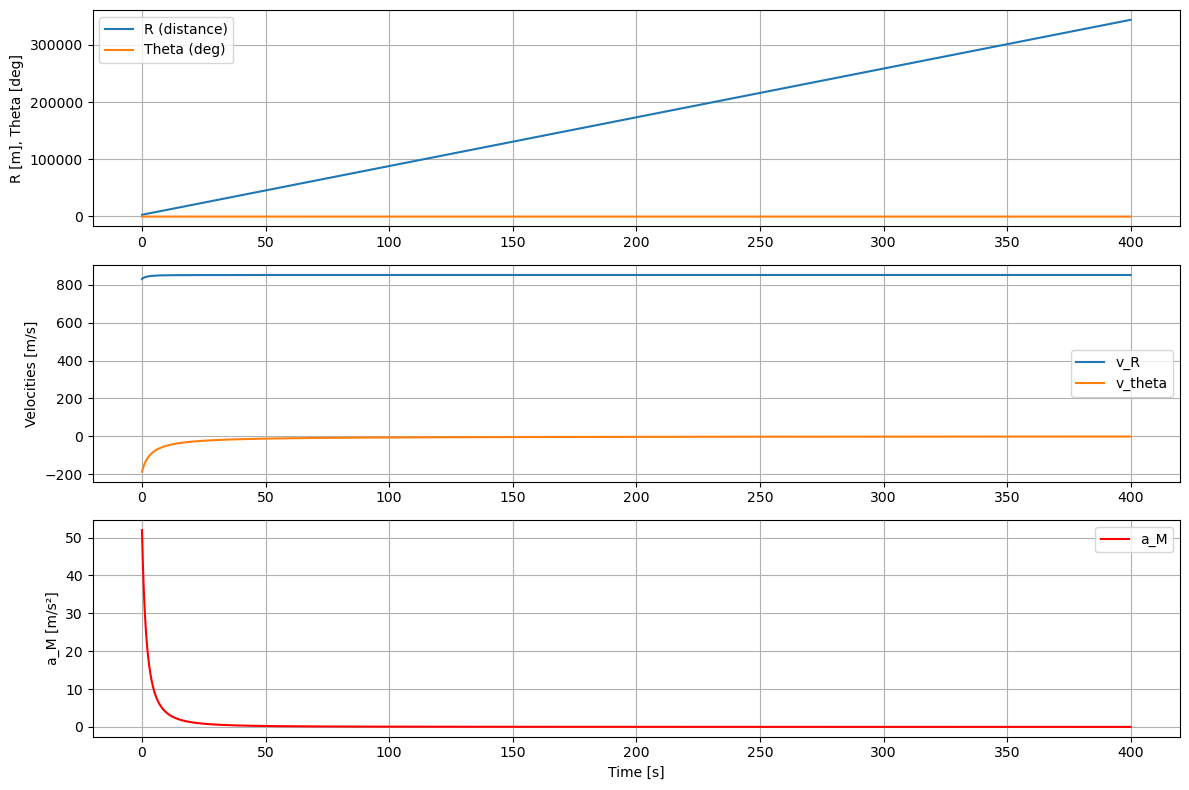

In [16]:
import numpy as np
import matplotlib.pyplot as plt 

# Defining variables
r = 3000

v_T = 300
nu = 2
v_P = nu * v_T

theta = np.deg2rad(30)
alpha_T = np.deg2rad(170)
delta = np.deg2rad(0) # Pure Pursuit
alpha_P = theta + delta 

t = 0
dt = 0.1
Tmax = 400

vx_T = v_T * np.cos(alpha_T)
vy_T = v_T * np.sin(alpha_T)
vx_P = v_P * np.cos(alpha_P)
vy_P = v_P * np.sin(alpha_P)

x_T = 0
y_T = 0
x_P = r * np.cos(theta)
y_P = r * np.sin(theta)
CR = 100

# Lists to store trajectory points
x_T_points = []
y_T_points = []
x_P_points = []
y_P_points = [] 
R_points = []
theta_points = []
v_theta_points = []
v_R_points = []
a_M_points = []

# Simulation loop
while np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2) > CR and t<Tmax: # Capture Condition
    
    R = np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2) 

    x_T_points.append(x_T)
    y_T_points.append(y_T)
    x_P_points.append(x_P)
    y_P_points.append(y_P)
    theta_points.append(theta)
    R_points.append(R)

    x_T += vx_T * dt
    y_T += vy_T * dt

    x_P += vx_P * dt
    y_P += vy_P * dt

    theta = np.arctan2(y_T - y_P, x_T - x_P)
    vx_P = v_P * np.cos(alpha_P)
    vy_P = v_P * np.sin(alpha_P)
    
    v_R = (vx_T - vx_P) * np.cos(theta) + (vy_T - vy_P) * np.sin(theta)
    v_theta = -(vx_T - vx_P) * np.sin(theta) + (vy_T - vy_P) * np.cos(theta)
    a_M = -v_R*v_theta / R

    t += dt

    R = np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2)
    
    v_R_points.append(v_R)
    v_theta_points.append(v_theta)
    a_M_points.append(a_M)

    if len(R_points) > 3 :
        if R_points[-3] > R_points[-2] and R_points[-2] < R_points[-1] :
            print("Target Missed!")
            print("Miss Distance: ", R)
            print("Time of flight: ", t)
            x_T_points.pop(-1)
            y_T_points.pop(-1)
            x_P_points.pop(-1)
            y_P_points.pop(-1)
            theta_points.pop(-1)
            R_points.pop(-1)
            v_R_points.pop(-1)
            v_theta_points.pop(-1)
            a_M_points.pop(-1)
            break

time = np.arange(len(R_points)) * dt

if R_points[-1] <= CR:
    print("Target Captured at t =", t)
else:
    print("Target Missed (sim ended at Tmax)")
    print("Miss Distance =", R_points[-1])

plt.figure(figsize=(12,8))

# 1) R and theta
plt.subplot(3,1,1)
plt.plot(time, R_points, label="R (distance)")
plt.plot(time, np.rad2deg(theta_points), label="Theta (deg)")
plt.ylabel("R [m], Theta [deg]")
plt.legend()
plt.grid(True)

# 2) v_R and v_theta
plt.subplot(3,1,2)
plt.plot(time, v_R_points, label="v_R")
plt.plot(time, v_theta_points, label="v_theta")
plt.ylabel("Velocities [m/s]")
plt.legend()
plt.grid(True)

# 3) a_M
plt.subplot(3,1,3)
plt.plot(time, a_M_points, label="a_M", color="r")
plt.xlabel("Time [s]")
plt.ylabel("a_M [m/s²]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




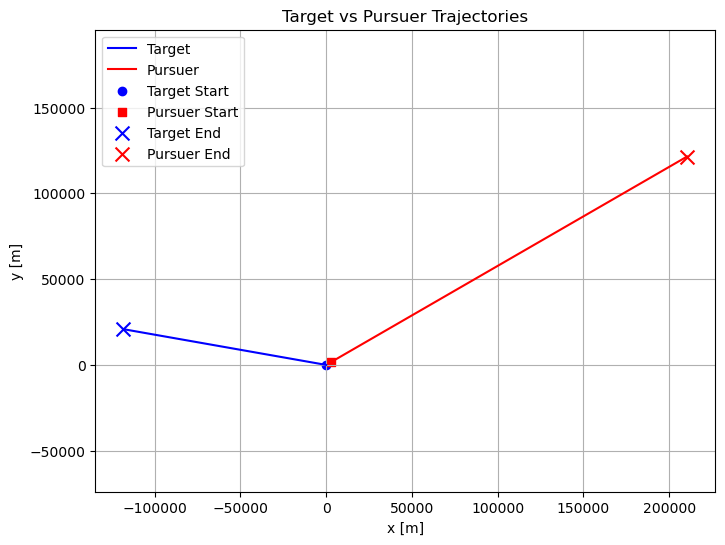

In [17]:
plt.figure(figsize=(8,6))

# Target trajectory
plt.plot(x_T_points, y_T_points, label="Target", color="blue")

# Pursuer trajectory
plt.plot(x_P_points, y_P_points, label="Pursuer", color="red")

# Starting positions
plt.scatter(x_T_points[0], y_T_points[0], color="blue", marker="o", label="Target Start")
plt.scatter(x_P_points[0], y_P_points[0], color="red", marker="s", label="Pursuer Start")

# Ending positions
plt.scatter(x_T_points[-1], y_T_points[-1], color="blue", marker="x", s=100, label="Target End")
plt.scatter(x_P_points[-1], y_P_points[-1], color="red", marker="x", s=100, label="Pursuer End")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Target vs Pursuer Trajectories")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()
